# Финальное сравнение моделей: LightGBM Baseline vs LSTM

In [1]:
import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.models.dataset import FitnessSequenceDataset
from src.models.lstm import LSTMRegressor
from src.eval.metrics import evaluate

FEATURE_COLS = [
    'steps_lag_1', 'steps_lag_3', 'steps_lag_7',
    'calories_lag_1', 'calories_lag_3', 'calories_lag_7',
    'steps_roll_mean_3', 'steps_roll_mean_7', 'steps_roll_mean_14',
    'steps_roll_std_3', 'steps_roll_std_7', 'steps_roll_std_14',
    'day_of_week', 'is_weekend', 'day_of_month', 'month', 'activity_streak',
]
print('Imports OK')

Imports OK


## 1. Загрузка тестовых данных

In [2]:
df = pd.read_parquet('../data/processed/train_features.parquet')
n = len(df)
test_df = df.iloc[int(n * 0.8):].copy().dropna(subset=FEATURE_COLS + ['target'])
print(f'Test samples: {len(test_df)}')
X_test = test_df[FEATURE_COLS].values
y_test = test_df['target'].values

Test samples: 55


## 2. Предсказания LightGBM

In [3]:
with open('../models/baseline_lgbm.pkl', 'rb') as f:
    lgbm_model = pickle.load(f)

lgbm_preds = lgbm_model.predict(X_test)
lgbm_metrics = evaluate(y_test, lgbm_preds)
print('LightGBM metrics:')
for k, v in lgbm_metrics.items():
    print(f'  {k.upper()}: {v:.2f}')

C:\Users\Acer\AppData\Local\pypoetry\Cache\virtualenvs\fitness-activity-prediction-NhWzKg-_-py3.11\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM metrics:
  MAE: 4008.35
  RMSE: 5180.27
  MAPE: 38.38


## 3. Предсказания LSTM

In [4]:
train_df = df.iloc[:int(n * 0.8)].copy()
train_dataset = FitnessSequenceDataset(train_df, sequence_length=7, fit_scaler=True)
val_dataset = FitnessSequenceDataset(test_df, sequence_length=7, scaler=train_dataset.scaler)

lstm_model = LSTMRegressor(input_size=17, hidden_size=64, num_layers=2, dropout=0.2)
lstm_model.load_state_dict(torch.load('../models/lstm_v1.pt', map_location='cpu'))
lstm_model.eval()

loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
lstm_preds, lstm_targets = [], []
with torch.no_grad():
    for X, y in loader:
        lstm_preds.extend(lstm_model(X).numpy().flatten())
        lstm_targets.extend(y.numpy().flatten())

lstm_preds = np.array(lstm_preds)
lstm_targets = np.array(lstm_targets)
lstm_metrics = evaluate(lstm_targets, lstm_preds)
print('LSTM metrics:')
for k, v in lstm_metrics.items():
    print(f'  {k.upper()}: {v:.2f}')

Scaler сохранён: models\scaler.pkl
Dataset: 77 sequences, shape=(77, 7, 17)
Dataset: 15 sequences, shape=(15, 7, 17)
LSTM metrics:
  MAE: 11445.93
  RMSE: 13243.31
  MAPE: 99.83


## 4. Сравнительная таблица

In [5]:
results = pd.DataFrame({
    'Model': ['LightGBM Baseline', 'LSTM v1'],
    'MAE': [lgbm_metrics['mae'], lstm_metrics['mae']],
    'RMSE': [lgbm_metrics['rmse'], lstm_metrics['rmse']],
    'MAPE (%)': [lgbm_metrics['mape'], lstm_metrics['mape']],
}).round(2)
print(results.to_string(index=False))

            Model      MAE     RMSE  MAPE (%)
LightGBM Baseline  4008.35  5180.27     38.38
          LSTM v1 11445.93 13243.31     99.83


## 5. График: Pred vs True

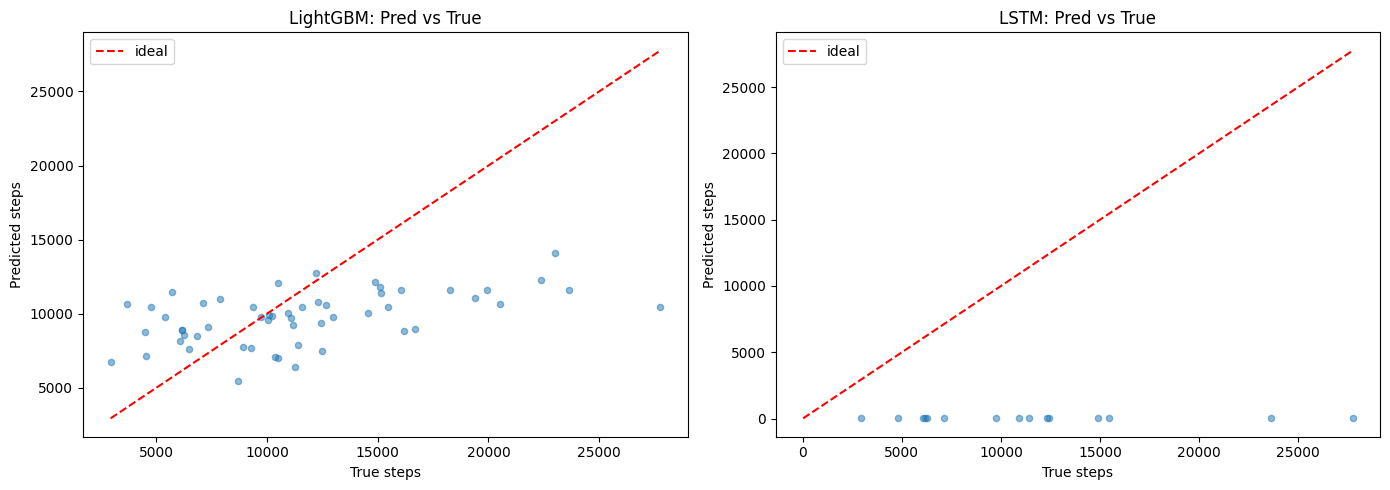

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, targets, title in [
    (axes[0], lgbm_preds[:len(y_test)], y_test, 'LightGBM: Pred vs True'),
    (axes[1], lstm_preds, lstm_targets, 'LSTM: Pred vs True'),
]:
    ax.scatter(targets, preds, alpha=0.5, s=20)
    mn, mx = min(targets.min(), preds.min()), max(targets.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='ideal')
    ax.set_xlabel('True steps')
    ax.set_ylabel('Predicted steps')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../report/pred_vs_true.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. График: Распределение ошибок

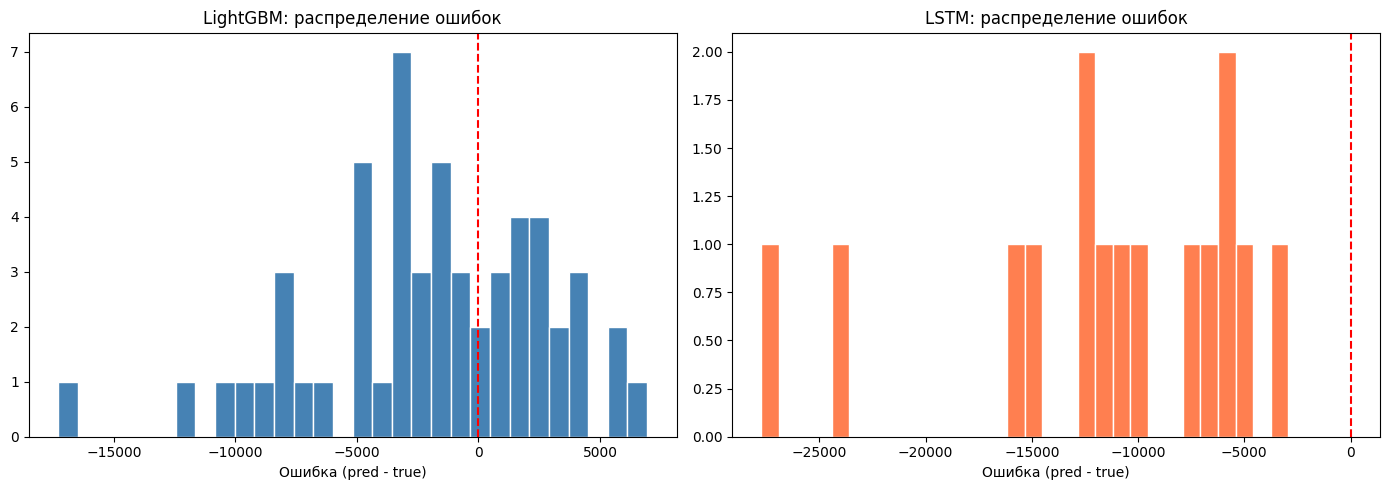

In [7]:
lgbm_errors = lgbm_preds[:len(y_test)] - y_test
lstm_errors = lstm_preds - lstm_targets

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lgbm_errors, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('LightGBM: распределение ошибок')
axes[0].set_xlabel('Ошибка (pred - true)')

axes[1].hist(lstm_errors, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('LSTM: распределение ошибок')
axes[1].set_xlabel('Ошибка (pred - true)')

plt.tight_layout()
plt.savefig('../report/error_distribution.png', dpi=100, bbox_inches='tight')
plt.show()